In [ ]:
from transformers import pipeline, Pipeline
from PIL import Image as PILImageModule
from PIL.Image import Image
import numpy.typing as npt
import numpy as np

In [ ]:
from utils.metrics import calc_mask_iou
sam_pipeline = pipeline("mask-generation", model="facebook/sam-vit-huge", device=0)

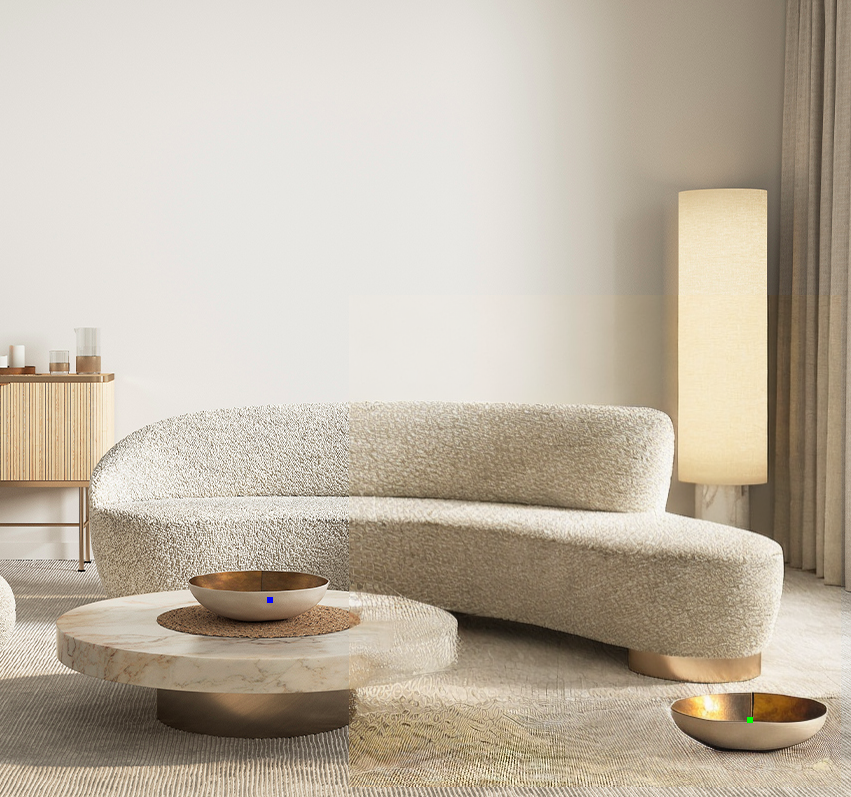

In [16]:
from utils.vis import draw_depth_pts
source_px = np.array([270, 600])
target_px = np.array([750, 720])
pil_image: Image = PILImageModule.open("results/new_object_placement/2025-11-16-21-58-18/0/result.png")
image = np.asarray(pil_image)
image_with_pts = draw_depth_pts(image, source_px, target_px)
PILImageModule.fromarray(image_with_pts).show()

In [ ]:
iou = calc_mask_iou(source_px, image, target_px, image, sam_pipeline)
print(iou)

0.0

In [25]:
from utils.img_proc import get_object_mask


source_mask = get_object_mask(image, source_px, sam_pipeline)
observed_mask = get_object_mask(image, target_px, sam_pipeline)

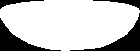

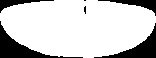

0.9470643557705226

In [43]:
# Get the mask bounding boxes
source_pil_mask = PILImageModule.fromarray(source_mask.astype(np.uint8)*255, mode="L")
source_bbox = source_pil_mask.getbbox()
source_crop = source_pil_mask.crop(source_bbox)
source_crop.show()

observed_pil_mask = PILImageModule.fromarray(observed_mask.astype(np.uint8)*255, mode="L")
observed_bbox = observed_pil_mask.getbbox()
observed_crop = observed_pil_mask.crop(observed_bbox)
observed_crop.show()

# Resize the source crop
source_crop = source_crop.resize(observed_crop.size)

# Compute IOU
source_crop_np = np.asarray(source_crop)
observed_crop_np = np.asarray(observed_crop)
intersection = np.logical_and(source_crop_np, observed_crop_np).sum()
union = np.logical_or(source_crop_np, observed_crop_np).sum()
float(intersection / union) if union > 0 else float("nan")
